# AAL Sales Analysis: Q4 2020

**Author:** Sandra Hershey-Zagrans
**Course:** UTD AI/ML Bootcamp, Unit 2 Project

Australian Apparel Ltd (AAL) is planning expansion and needs to know where its revenue actually comes from. This notebook analyzes fourth quarter 2020 sales across all seven states and four customer groups to answer two questions for the head of Sales and Marketing:

1. Which states generate the highest revenue?
2. Where should sales programs target underperforming states?

The analysis runs in four phases: data wrangling, statistical analysis, visualization, and recommendations.

## Section 1: Data Wrangling

Before any analysis, the data has to earn our trust. In this section I load the raw CSV, check its shape and data types, verify there are no missing values using `isna()` and `notna()`, and look for incorrect entries that would silently corrupt the analysis downstream.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/AusApparalSales4thQrt2020.csv")
print(df.shape)
df.info()
df.isna().sum(), df.notna().sum()

(7560, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


(Date     0
 Time     0
 State    0
 Group    0
 Unit     0
 Sales    0
 dtype: int64,
 Date     7560
 Time     7560
 State    7560
 Group    7560
 Unit     7560
 Sales    7560
 dtype: int64)

### Inspection results

The dataset contains 7,560 rows and 6 columns covering October through December 2020. The `isna()` and `notna()` checks confirm there are **zero missing values** in any column, so no imputation or row dropping is required.

Two problems did surface, though:

1. **Date imported as a string** instead of a datetime, which would block any time-based reporting.
2. **Every value in the Time, State, and Group columns carries a leading space** (for example `' WA'` instead of `'WA'`). This is the sneaky kind of incorrect entry: nothing looks wrong at a glance, but a filter like `df[df["State"] == "WA"]` returns zero rows, and every chart label would be quietly padded.

Both are fixed in the next cell.

In [12]:
# Reveal the hidden problem: leading whitespace in every categorical value
print("Before:", df["State"].unique())

for col in ["Time", "State", "Group"]:
    df[col] = df[col].str.strip()

df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%Y")

print("After:", df["State"].unique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

Before: [' WA' ' NT' ' SA' ' VIC' ' QLD' ' NSW' ' TAS']
After: ['WA' 'NT' 'SA' 'VIC' 'QLD' 'NSW' 'TAS']
Date range: 2020-10-01 to 2020-12-30


### Missing and incorrect data: treatment recommendation

**What I found:** No missing values, but two data quality issues, both now treated:

- Leading whitespace in all categorical columns, removed with `str.strip()`
- Date stored as text, converted with `pd.to_datetime()`

**What I would recommend if missing values had existed:**

- For numeric columns (`Unit`, `Sales`): impute with the **median per State and Group** rather than dropping rows. The dataset covers a single quarter, so every row carries real information, and the median resists distortion from skewed sales figures better than the mean would.
- For categorical columns (`State`, `Group`, `Time`): **drop the affected rows**. There is no reliable way to guess which state or customer group a sale belongs to, and a wrong guess is worse than a smaller dataset.

The guiding principle: impute when a reasonable estimate exists, drop when guessing would inject noise.

In [13]:
from sklearn.preprocessing import MinMaxScaler

print("Before:")
print(df[["Unit", "Sales"]].describe().loc[["min", "max", "mean"]])

scaler = MinMaxScaler()
df[["Unit_norm", "Sales_norm"]] = scaler.fit_transform(df[["Unit", "Sales"]])

print("\nAfter:")
print(df[["Unit_norm", "Sales_norm"]].describe().loc[["min", "max", "mean"]])

print("\nCorrelation between Unit and Sales:", df["Unit"].corr(df["Sales"]))

Before:
           Unit          Sales
min    2.000000    5000.000000
max   65.000000  162500.000000
mean  18.005423   45013.558201

After:
      Unit_norm  Sales_norm
min    0.000000    0.000000
max    1.000000    1.000000
mean   0.254054    0.254054

Correlation between Unit and Sales: 0.9999999999999999


### Normalization: method choice and results

I used **Min-Max normalization** to rescale `Unit` and `Sales` into the range [0, 1], keeping the original columns for dollar-figure reporting.

**Why normalization over standardization:** Standardization (z-scores) assumes roughly Gaussian data and is the right tool when feeding distance-based models. This sales data is skewed retail data, and the goal here is comparability for reporting and visualization, not modeling. Min-Max rescaling preserves the exact shape of each distribution while putting both columns on a common scale, which is all this problem needs.

**Results:** Both normalized columns span [0, 1] with a mean of 0.254, confirming that sales cluster toward the lower end with a smaller number of high-volume transactions.

**An unexpected finding:** `Unit` and `Sales` correlate perfectly (r = 1.0). Every row satisfies Sales = Unit × 2500, meaning AAL records a flat $2,500 per unit across all states, groups, and times. Practically, this means unit volume analysis and revenue analysis are interchangeable for this dataset, and any pattern we find in one automatically holds in the other.

In [14]:
# GroupBy as data chunking: split-apply-combine
print("Revenue by State:")
print(df.groupby("State")["Sales"].sum().sort_values(ascending=False))

print("\nRevenue by Group:")
print(df.groupby("Group")["Sales"].sum().sort_values(ascending=False))

print("\nRevenue by State and Group:")
print(df.groupby(["State", "Group"])["Sales"].agg(["sum", "mean"]).round(0))

Revenue by State:
State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

Revenue by Group:
Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

Revenue by State and Group:
                    sum     mean
State Group                     
NSW   Kids     18587500  68843.0
      Men      19022500  70454.0
      Seniors  18187500  67361.0
      Women    19172500  71009.0
NT    Kids      5700000  21111.0
      Men       5762500  21343.0
      Seniors   5465000  20241.0
      Women     5652500  20935.0
QLD   Kids      8510000  31519.0
      Men       8392500  31083.0
      Seniors   8190000  30333.0
      Women     8325000  30833.0
SA    Kids     14515000  53759.0
      Men      14655000  54278.0
      Seniors  14717500  54509.0
      Women    14970000  55444.0
TAS   Kids      5775000  21389.0
      Men       5757500  21324.0
      Senio

### GroupBy: chunking vs. merging, and a recommendation

`groupby()` supports two distinct workflows. **Chunking** follows the split-apply-combine pattern: divide the table into groups, aggregate each chunk, and recombine the results into a summary. **Merging** joins separate tables on a shared key using `pd.merge()`, with groupby sometimes preparing one side of the join.

**Recommendation: chunking.** This project has a single table, and every business question takes the form "revenue by state," "revenue by group," or "revenue by time period." That is precisely what chunked aggregation answers. Merging would only become relevant if we had a second table to join, such as store locations or marketing spend per state. With one table and aggregate questions, chunking is the whole job.

**First findings from the chunked summaries:** Revenue varies enormously by geography and barely at all by demographics. VIC leads at $105.6M, nearly five times last-place WA at $22.2M, with three clear tiers: VIC and NSW on top, SA and QLD in the middle, and TAS, NT, and WA grouped at the bottom near $22M each. The four customer groups sit within about 2% of each other (Men $85.7M to Seniors $84.0M). The expansion question is therefore a geography question, not a demographics question.

## Section 2: Data Analysis

Descriptive statistics on the Sales and Unit columns using Pandas and SciPy, followed by identification of the highest and lowest performing states and customer groups, and weekly, monthly, and quarterly summary reports.

In [15]:
from scipy import stats

for col in ["Sales", "Unit"]:
    print(f"--- {col} ---")
    print(f"Mean:   {df[col].mean():,.2f}")
    print(f"Median: {df[col].median():,.2f}")
    print(f"Mode:   {df[col].mode()[0]:,}")
    print(f"Std:    {df[col].std():,.2f}\n")

# SciPy for the statistical analysis requirement
mode_result = stats.mode(df["Sales"], keepdims=True)
print(f"SciPy mode: {mode_result.mode[0]:,} occurring {mode_result.count[0]} times")
print(f"Sales skewness: {df['Sales'].skew():.2f}")

# Highest and lowest performers
state_sales = df.groupby("State")["Sales"].sum()
group_sales = df.groupby("Group")["Sales"].sum()
print(f"\nHighest state: {state_sales.idxmax()} (${state_sales.max():,})")
print(f"Lowest state:  {state_sales.idxmin()} (${state_sales.min():,})")
print(f"Highest group: {group_sales.idxmax()} (${group_sales.max():,})")
print(f"Lowest group:  {group_sales.idxmin()} (${group_sales.min():,})")

--- Sales ---
Mean:   45,013.56
Median: 35,000.00
Mode:   22,500
Std:    32,253.51

--- Unit ---
Mean:   18.01
Median: 14.00
Mode:   9
Std:    12.90

SciPy mode: 22,500 occurring 406 times
Sales skewness: 1.09

Highest state: VIC ($105,565,000)
Lowest state:  WA ($22,152,500)
Highest group: Men ($85,750,000)
Lowest group:  Seniors ($84,037,500)


### What the statistics say

**Sales:** mean $45,014, median $35,000, mode $22,500, standard deviation $32,254.
**Unit:** mean 18.0, median 14, mode 9, standard deviation 12.9.

The ordering mean > median > mode is the classic signature of a **right-skewed distribution** (skewness = 1.09). Most transactions are modest, while a smaller number of high-volume sales pull the mean upward. This also validates the earlier choice of median over mean for any imputation: the mean is not a reliable "typical value" for skewed data. The standard deviation is roughly 72% of the mean, so sales volume is highly variable rather than steady.

**Performance extremes:**

- Highest revenue state: **VIC** at $105.6M
- Lowest revenue state: **WA** at $22.2M
- Highest revenue group: **Men** at $85.8M
- Lowest revenue group: **Seniors** at $84.0M

The state gap is nearly 5x while the group gap is about 2%, reinforcing the Section 1 finding: geography drives revenue differences, demographics do not.

In [16]:
ts = df.set_index("Date")

weekly = ts.resample("W")["Sales"].sum()
monthly = ts.resample("ME")["Sales"].sum()
quarterly = ts.resample("QE")["Sales"].sum()

print("Weekly:\n", weekly, "\n")
print("Monthly:\n", monthly, "\n")
print("Quarterly:\n", quarterly, "\n")
print("Month-over-month growth:\n", monthly.pct_change())

Weekly:
 Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64 

Monthly:
 Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64 

Quarterly:
 Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64 

Month-over-month growth:
 Date
2020-10-31         NaN
2020-11-30   -0.206558
2020-12-31    0.492350
Freq: ME, Name: Sales, dtype: float64


### Weekly, monthly, and quarterly reports

Setting the Date column as the index lets `resample()` regroup the data by time period, the same split-apply-combine idea as `groupby()` but with time as the grouping key.

**Quarterly:** Q4 2020 total revenue was **$340.3M**.

**Monthly:** October $114.3M, November $90.7M, December $135.3M. November dipped 20.7% from October, then December surged 49.2%, a classic holiday-season pattern. December alone contributed roughly 40% of the quarter.

**Weekly:** November held a flat plateau near $21M per week, while every December week from the 6th onward ran between $29M and $32M, confirming the holiday ramp was sustained rather than a single spike.

**A note on reading the weekly output:** the first and last weekly figures appear low, but these are partial weeks. Pandas bins weeks ending Sunday, so the first bin covers only October 1 through 4 and the last covers only December 28 through 30. They reflect fewer days, not weaker sales.

## Section 3: Data Visualization

**Library recommendation: Seaborn.** This analysis is statistical in nature, and Seaborn is purpose-built for statistical graphics: it aggregates within the plotting call itself, offers distribution plots and box plots as first-class citizens, and produces clean, readable defaults. Because it layers on top of Matplotlib, full fine-grained control remains available when needed. Matplotlib alone would require manual aggregation for every chart, and interactive libraries like Plotly add complexity this reporting task does not need.

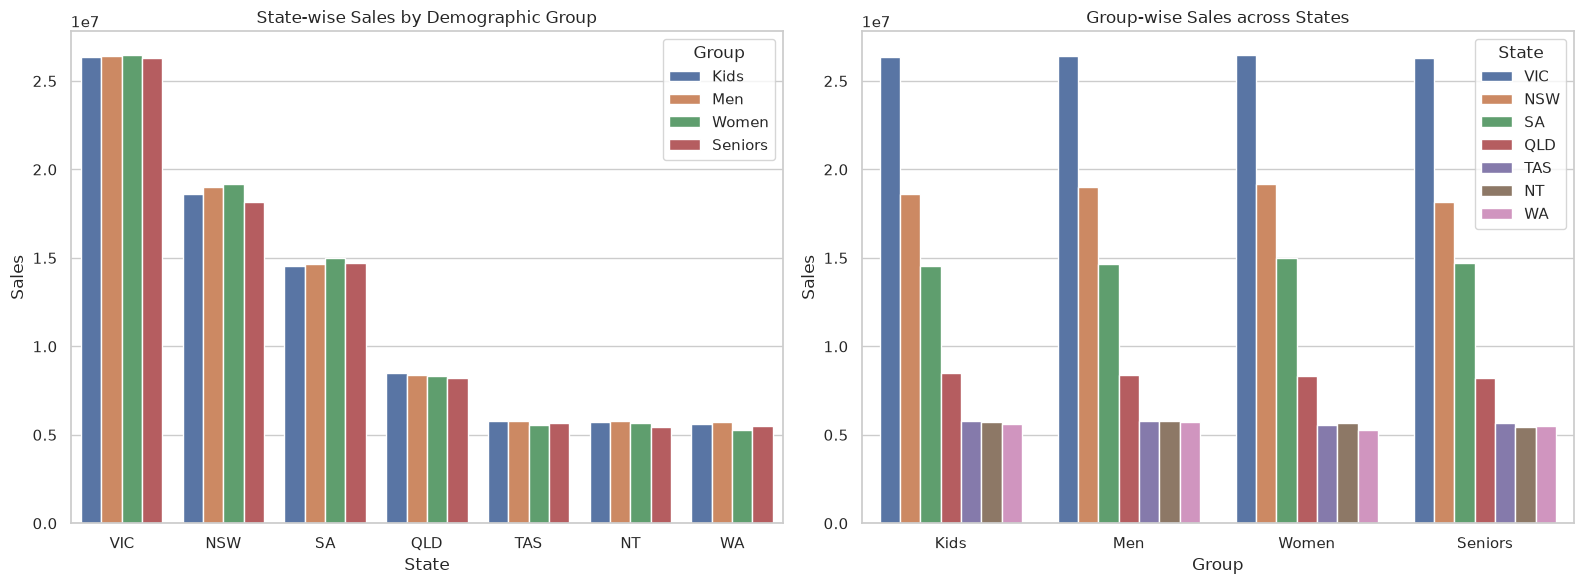

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
state_order = df.groupby("State")["Sales"].sum().sort_values(ascending=False).index

sns.barplot(data=df, x="State", y="Sales", hue="Group", estimator=sum,
            errorbar=None, order=state_order, ax=axes[0])
axes[0].set_title("State-wise Sales by Demographic Group")

sns.barplot(data=df, x="Group", y="Sales", hue="State", estimator=sum,
            errorbar=None, hue_order=state_order, ax=axes[1])
axes[1].set_title("Group-wise Sales across States")
plt.tight_layout()
plt.show()

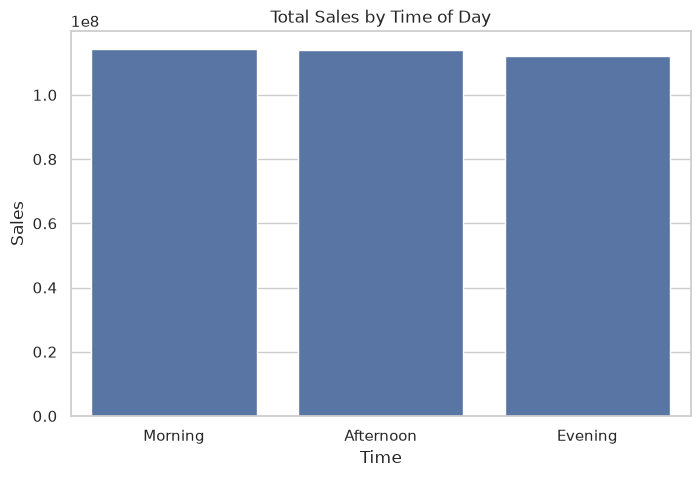

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64


In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Time", y="Sales", estimator=sum, errorbar=None,
            order=["Morning", "Afternoon", "Evening"])
plt.title("Total Sales by Time of Day")
plt.show()

print(df.groupby("Time")["Sales"].sum().sort_values(ascending=False))

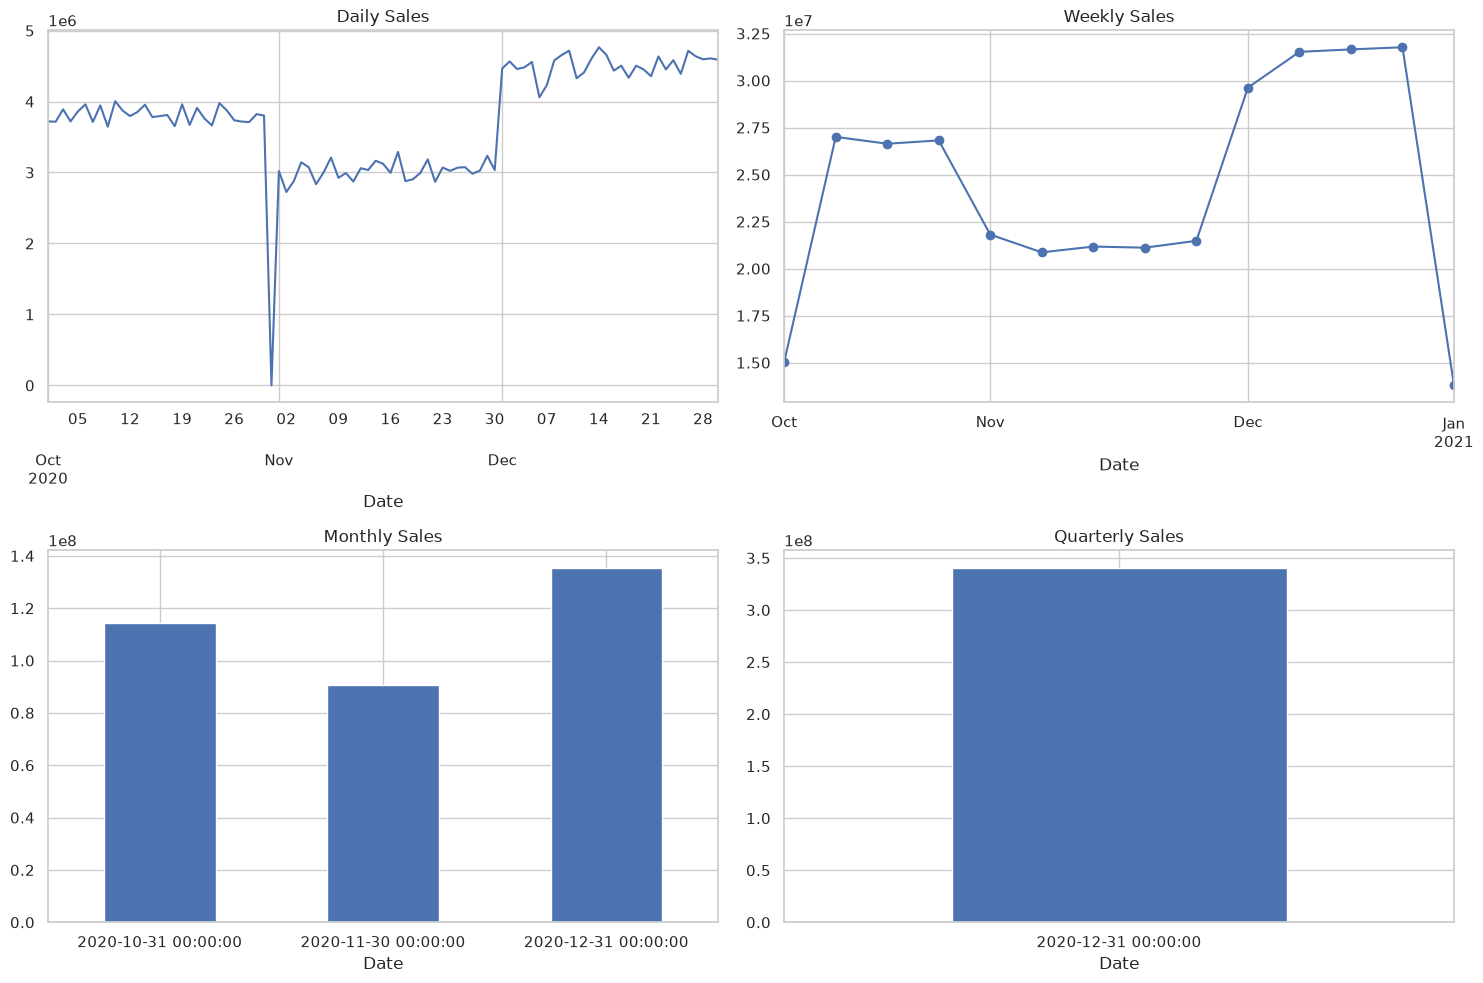

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ts.resample("D")["Sales"].sum().plot(ax=axes[0,0], title="Daily Sales")
ts.resample("W")["Sales"].sum().plot(ax=axes[0,1], marker="o", title="Weekly Sales")
ts.resample("ME")["Sales"].sum().plot(ax=axes[1,0], kind="bar", title="Monthly Sales", rot=0)
ts.resample("QE")["Sales"].sum().plot(ax=axes[1,1], kind="bar", title="Quarterly Sales", rot=0)
plt.tight_layout()
plt.show()

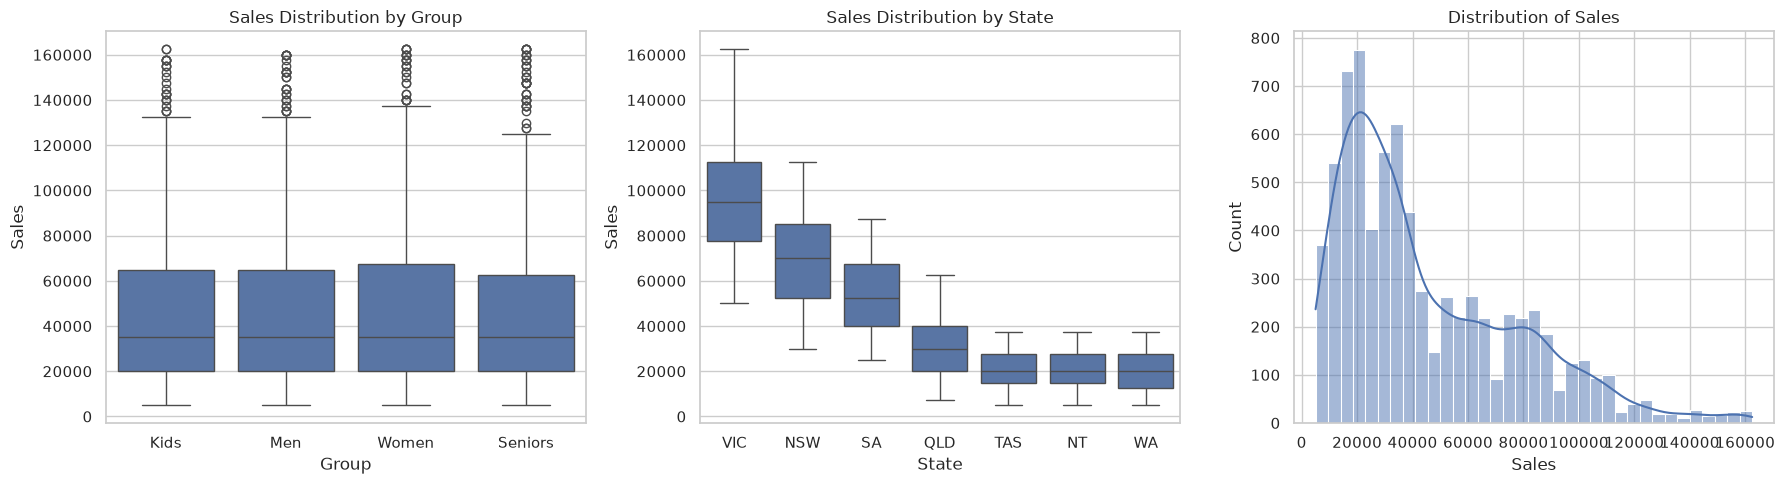

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x="Group", y="Sales", ax=axes[0])
axes[0].set_title("Sales Distribution by Group")
sns.boxplot(data=df, x="State", y="Sales", order=state_order, ax=axes[1])
axes[1].set_title("Sales Distribution by State")
sns.histplot(df["Sales"], kde=True, ax=axes[2])
axes[2].set_title("Distribution of Sales")
plt.tight_layout()
plt.show()

### Reading the dashboard

**State-wise and group-wise views:** VIC towers over every other state in all four demographic groups, with NSW second. Within any single state, the four group bars are nearly identical heights. The pattern is unmistakable: state determines revenue, customer group does not.

**Time of day:** Morning ($114.2M), Afternoon ($114.0M), and Evening ($112.1M) differ by less than 2%. There is no meaningful peak or off-peak period in this data. For the S&M team, this means hyper-personalization and Next Best Offer programs should not be scheduled around time of day; the levers that matter are geographic targeting and seasonal timing.

**Time granularities:** The daily and weekly charts show November's flat plateau and the sustained December ramp. The monthly chart makes the holiday surge explicit, and the quarterly bar totals the quarter at $340.3M.

**Box plots and distribution:** The distribution plot confirms the right skew found in Section 2 (mean above median, long right tail). The box plots show that this skew appears within every group and state: medians sit low in each box with outliers extending upward, meaning high-value transactions occur everywhere but are nowhere the norm.

## Section 4: Findings and Recommendations

### Executive summary

Q4 2020 revenue totaled **$340.3M** across seven states and four customer groups. Five findings stand out:

1. **Geography is the dominant revenue driver.** VIC generated $105.6M, nearly five times last-place WA at $22.2M. The states form three tiers: VIC and NSW on top ($180.5M combined, 53% of the quarter), SA and QLD in the middle, and TAS, NT, and WA clustered at the bottom near $22M each.

2. **Demographics are flat.** The four customer groups all landed within 2% of each other (Men $85.8M to Seniors $84.0M). No group is underperforming anywhere.

3. **Time of day is flat.** Morning, Afternoon, and Evening each produced roughly $112M to $114M. There is no peak shopping window to exploit.

4. **Seasonality is strong.** November dipped 20.7% below October, then December surged 49.2% to $135.3M, contributing about 40% of the quarter on its own.

5. **Pricing is uniform.** Every transaction resolves to exactly $2,500 per unit, so unit volume and revenue are interchangeable measures in this data.

### Recommendations for the head of Sales and Marketing

**1. Concentrate expansion capital in VIC and NSW.** These two states carry 53% of national revenue and represent proven demand. New store locations and inventory depth should follow the revenue, not spread evenly across the map.

**2. Treat TAS, NT, and WA as one program, not three.** The three bottom states perform almost identically (within $600K of each other), which suggests a shared cause such as lower brand penetration or thinner store coverage rather than three separate local problems. A single low-tier growth program with localized execution will be cheaper and more coherent than three independent efforts. Before spending, investigate per-capita performance: WA is a large state, and if revenue per resident lags the national average, awareness marketing is the likely fix; if per-capita sales are normal, the ceiling is population, and heavy investment there will not pay back.

**3. Do not build campaigns around demographics or time of day.** The data shows no group and no daypart worth targeting over another. Marketing spend aimed at a specific age group or evening promotion window would be optimizing a variable that does not move revenue. Redirect that budget toward geographic and seasonal levers.

**4. Plan around the November trough.** The 20.7% November dip precedes the December surge every retailer expects. A November promotion window (early holiday pricing, loyalty previews) could pull demand forward and smooth the quarter, and inventory built in November positions stores for the December ramp.

**5. Question the flat $2,500 unit price.** Uniform pricing across states, groups, and dayparts means AAL is leaving price discovery on the table. Even modest regional or seasonal price testing in Q1 would reveal whether the top states can bear premium pricing or whether the bottom tier responds to discounts.